In [4]:
import torch
from torch.utils.data import Dataset
from transformers import Trainer, TrainingArguments, ViTImageProcessor, BertTokenizer, VisionEncoderDecoderModel

import torch
from torch.utils.data import Dataset
import os
import cv2
import numpy as np

from PIL import Image, ImageFile
from tqdm import tqdm
import xml.etree.ElementTree as ET


import re

# Add ../ as a directory to import from
import sys
sys.path.append('../')

from plant_dataset import load_sideview_images
from image_process import process_leaf_image
from plant_tokenizer import vec2token, SOS_TOKEN, EOS_TOKEN, PAD_TOKEN, VOCAB_SIZE
from string_to_xml_to_vec import xml2vec, linked_to_recursive
from plant_dataset import PlantDataset


device = "cuda" if torch.cuda.is_available() else "cpu"
# import torch
# print(torch.cuda.is_available())
# print(torch.cuda.device_count())
# print(torch.cuda.current_device())
# print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No CUDA device")


In [5]:
from transformers import VisionEncoderDecoderModel
from utils import model_summary
from transformers import AutoImageProcessor, AutoModel
import re
from models.model import PlantArchitectureModel
from transformers import VisionEncoderDecoderModel, BertConfig, BertModel, ViTModel, AutoConfig, GPT2Config, AutoImageProcessor

checkpoint_path = "heesup/dinov2-small_448_Sideview_gpt2-medium"
model = PlantArchitectureModel.from_pretrained(checkpoint_path,
                                    torch_dtype=torch.float16,).to(device)


# Set the model to evaluation mode
model.eval()

# Extract image size (looking for a number followed by underscore and Sideview or another word)
if "224" in checkpoint_path:
    image_size = 224
elif "448" in checkpoint_path:
    image_size = 448
else:
    image_size = 224

max_length = 4096 * 2
# Extract side_view (True if "Sideview" appears in the path, False otherwise)
side_view = "Sideview" in checkpoint_path

# Try to load the image processor from the encoder's config name
encoder_name = model.encoder.config._name_or_path
image_processor = AutoImageProcessor.from_pretrained(encoder_name)
image_processor.crop_size['width'] = image_size
image_processor.crop_size['height'] = image_size
image_processor.size['shortest_edge'] = image_size

model.safetensors:   0%|          | 0.00/1.74G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/709 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/119 [00:00<?, ?B/s]

In [6]:
model_summary(model)

  | Name    | Type            | Params | Mode | FLOPs
-----------------------------------------------------------
0 | encoder | Dinov2Model     | 22.1 M | eval | 0    
1 | decoder | GPT2LMHeadModel | 411 M  | eval | 0    
-----------------------------------------------------------
433 M     Trainable params
0         Non-trainable params
433 M     Total params
1,735.199 Total estimated model params size (MB)
0         Modules in train mode
712       Modules in eval mode
0         Total Flops


In [7]:
from torch.utils.data import random_split
# Set a random seed for reproducibility


# Dataset 인스턴스 생성
if 0:
    growth_stages = ["01"]
else:
    growth_stages = None


dataset_path = "/home/lion397/datasets/GEMINI/plant_architecture/20250311_Sideview_40Days"

dataset = PlantDataset(root_dir=dataset_path, stages=growth_stages, 
                       process_leaf=True, image_size=image_size,
                       side_view=side_view,
                       mode='train',
                       preload=False, add_sos_token=False,
                       image_processor=image_processor,
                       flip_test=False)

# Split the dataset into Train, Validation, and Test sets
train_size = int(0.8 * len(dataset))  # 80% for training
val_size = int(0.1 * len(dataset))    # 10% for validation
test_size = len(dataset) - train_size - val_size  # Remaining 10% for testing

# Use random_split with the seed set above
seed = 42
torch.manual_seed(seed)
train_dataset, val_dataset, test_dataset = random_split(dataset, [train_size, val_size, test_size])

Total 400000 images and plant strings loaded


In [8]:
# Path to the program for re-rendering XML files
program_path = "../CowpeaSimulator/build"

import os
import subprocess
# Function to re-render a single XML file
def re_render_xml(output_path, filename, rotation=True, debug=False):
    os.environ["DISPLAY"] = ":1.0"
    image_name = filename.split("/")[-1].split(".")[0]
    command = f"cd {program_path} && ./main -h 1.0 -o {output_path} -name {image_name} -tile none -f {os.path.join(output_path, filename)}"
    if rotation:
        command += " -r"
    result = subprocess.run(command, shell=True, capture_output=True, text=True)
    if debug:
        print(result.stdout)
        print(result.stderr)
    return result

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.1007793..2.1519825].


tensor([[223, 224,  71,  73,  72, 224,   0,  80, 162, 120,  93,  77,   1,  61,
          55,  40, 158,   2,  41,  44, 103, 144,  77,   3,  60,  80,  40,  34,
           6,  94,  34, 114,  93,  79,   7,  61,  53,  86, 137,   8,  65,  51,
          97, 116,  76,   9,  68,  93,  82,  34,  10,  68, 102,  40,  34,  11,
          68,  93,  36,  34,   7,  61,  53,  86, 150,   8,  65,  51, 100, 136,
          76,   9,  68,  96,  82,  34,  10,  68,  97,  40,  34,  11,  68,  96,
          36,  34,   7,  61,  53,  86, 148,   8,  65,  51, 100, 119,  76,   9,
          68,  96,  82,  34,  10,  68,  98,  40,  34,  11,  68,  96,  36,  34,
           7,  61,  53,  86, 148,   8,  65,  51, 100, 109,  76,   9,  68,  98,
          82,  34,  10,  68,  98,  40,  34,  11,  68,  96,  36,  34,  12, 100,
          38, 114,  93,  79,  13,  61,  51,  86, 148,  14,  65,  51,  97, 133,
          76,  15,  68,  96,  82,  34,  16,  68,  90,  40,  34,  17,  68,  98,
          36,  34,  13,  61,  51,  86, 148,  14,  65

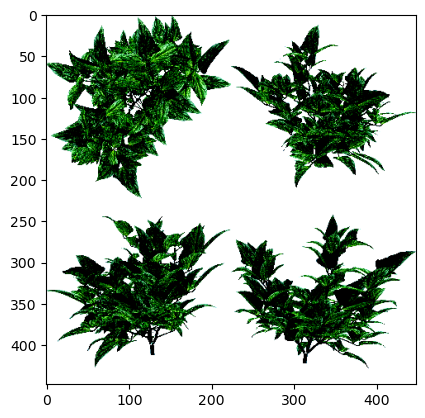

In [9]:
import matplotlib.pyplot as plt
for i in range(1):
    pixel_values = test_dataset[i]["pixel_values"].unsqueeze(0).to(model.device)
    plant_info = test_dataset[i]["plant_info"]
    plant_info = torch.tensor(plant_info, dtype=torch.long).unsqueeze(0).to(model.device)  # Ensure plant_info is a tens
    generated_ids = model.generate(pixel_values,
                                decoder_start_token_id=SOS_TOKEN,
                                decoder_input_ids=plant_info,
                                eos_token_id=EOS_TOKEN,
                                pad_token_id=PAD_TOKEN,
                                max_length=200
                                )
    print(generated_ids)

    image_vis = pixel_values.squeeze().permute(1,2,0).cpu().numpy()
    # image_vis = cv2.cvtColor(image_vis,cv2.COLOR_RGB2BGR)
    # image_vis = cv2.normalize(np.array(image_vis), None, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX, dtype=cv2.CV_8U)
    plt.figure()
    plt.imshow(image_vis)

    if hasattr(model,"predicted_depth"):
        plt.figure()
        plt.imshow(model.predicted_depth.cpu().squeeze().numpy())
        plt.colorbar()


In [10]:
generated_ids.shape

torch.Size([1, 200])

Total 1000 images and plant strings loaded


/tmp/ipykernel_990399/1930124255.py:96: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/home/lion397/codes/Image2PlantArchitecture/.env/lib/python3.12/site-packages/torch/cuda/amp/autocast_mode.py:54: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  super().__init__(
/tmp/ipykernel_990399/1930124255.py:132: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  image_vis = cv2.normalize(np.array(image_vis), None, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX, dtype=cv2.CV_8U)


KeyboardInterrupt: 

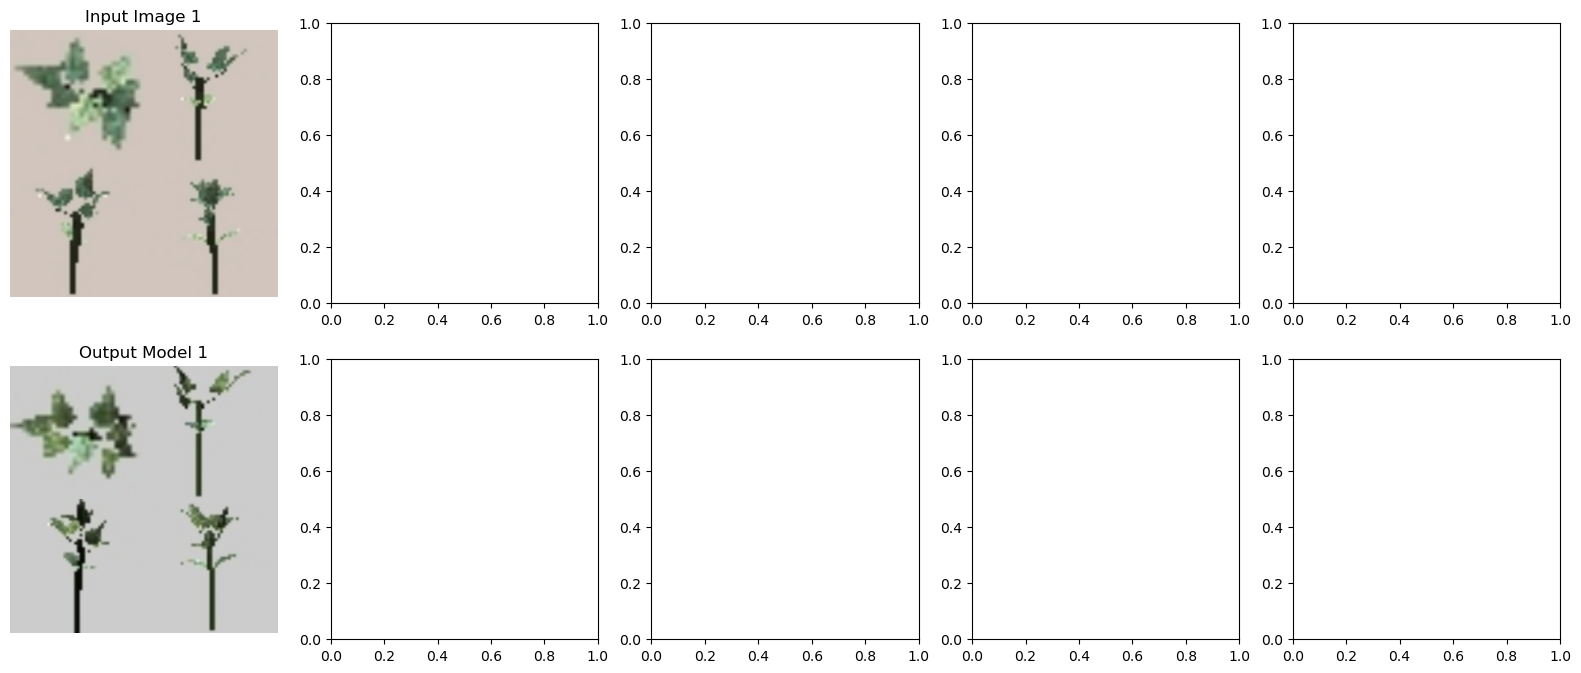

In [11]:
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
from plant_tokenizer import SOS_TOKEN, EOS_TOKEN
from models.model import get_tgt_mask
from plant_dataset import PlantDataset, load_sideview_images
from image_process import process_leaf_image
from plantstring2model import plantstring2model
from string_to_xml_to_vec import vec2xml, recursive_to_linked
from plant_tokenizer import token2vec
import shutil
from string_to_xml_to_vec import string2vec, vec2string, vec2xml, pretty_print_xml

  
# Dataset 인스턴스 생성
if 1:
    growth_stages = ["05"]
else:
    growth_stages = None


train_ratio = 0.8
val_ratio = 0.1
test_ratio = 0.1
xml_files = os.listdir(os.path.join(dataset_path, "xml"))
xml_files.sort()
num_plots = int(xml_files[-1].split("_")[1]) + 1

train_end = int(num_plots * train_ratio)
val_end = train_end + int(num_plots * val_ratio)
test_end = min(num_plots, val_end + int(num_plots * test_ratio)) # Ensure total sums up to num_plots

train_plots = [f"{plot:04d}" for plot in range(train_end)]
val_plots = [f"{plot:04d}" for plot in range(train_end, val_end)]
test_plots = [f"{plot:04d}" for plot in range(val_end, test_end)]

test_dataset = PlantDataset(root_dir=dataset_path, stages=growth_stages, 
            process_leaf=True, image_size=image_size,
            side_view=side_view,
            plot=test_plots,
            image_processor=image_processor,
            mode='test',
            preload=False, add_sos_token=False)

# Prepare the figure
n_figures = 5
fig, axes = plt.subplots(2, n_figures, figsize=(20, 8))

# Create temp folder
temp_folder = "temp"
shutil.rmtree(temp_folder, ignore_errors=True)
os.makedirs(temp_folder, exist_ok=True)

device = model.device
for idx, data in enumerate(test_dataset):
    if idx >= n_figures:
        break
    image = data["pixel_values"]
    out = data["labels"]
    plant_info = data["plant_info"]
    gt_plant_vec = data["plant_vec"]

    # print(dataloader.dataset.plant_xml_files[idx])
    if image.dim() == 3:
        image = image.unsqueeze(0)

    image = image.to(device)
    out = torch.tensor(out).to(device)
    if 0:
        ground_truth = out.squeeze(0).cpu().numpy()
        plant_vec = token2vec(ground_truth[5:])
    else:
        plant_vec = gt_plant_vec
        
    plant_xml = vec2xml(plant_vec)
    plant_xml_file_name = f"temp/plant_{idx}_gt.xml"
    plant_xml = recursive_to_linked(plant_xml)
    plant_xml_str = pretty_print_xml(plant_xml)
    with open(plant_xml_file_name, "w") as f:
        f.write(plant_xml_str)
   
    re_render_xml(os.path.abspath(temp_folder), os.path.abspath(plant_xml_file_name))
    if side_view:
        img, _ = load_sideview_images(temp_folder, plant_xml_file_name.replace("xml","jpeg"), 224, True)
    else:
        img = cv2.imread(plant_xml_file_name.replace("xml","jpeg"))
        img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
        leaf_area, plant_width, plant_height, leaf_img, _ = process_leaf_image(img, sqaure_crop=True, thr=0.0)
        img = cv2.resize(leaf_img, (image_size, image_size))
    gt_img = img.copy()
    ############## Generate

    with torch.no_grad():
        plant_info = torch.tensor(plant_info, dtype=torch.long).unsqueeze(0).to(model.device)  # Ensure plant_info is a tens
        with torch.cuda.amp.autocast():
            result = model.generate(image,
                                    decoder_start_token_id=SOS_TOKEN,
                                    decoder_input_ids=plant_info,
                                    eos_token_id=EOS_TOKEN,
                                    pad_token_id=PAD_TOKEN,
                                    # do_sample=True,
                                    # num_beams=5,
                                    # early_stopping=True,  # Stop when EOS is generated
                                    output_attentions=False,  # Don't compute attentions
                                    max_length=max_length,
                                    output_hidden_states=False,  # Don't compute hidden states
                                    repetition_penalty=1.1,  # Avoid repetitive sequences
                                    use_cache=True,
                                    )
            result = result.squeeze().cpu().numpy()[6:]

    plant_vec = token2vec(result)
    plant_xml = vec2xml(plant_vec)
    plant_xml_file_name = f"temp/plant_{idx}_est.xml"
    plant_xml = recursive_to_linked(plant_xml)
    plant_xml_str = pretty_print_xml(plant_xml)
    with open(plant_xml_file_name, "w") as f:
        f.write(plant_xml_str)

    re_render_xml(os.path.abspath(temp_folder), os.path.abspath(plant_xml_file_name))

    if side_view:
        img, _ = load_sideview_images(temp_folder, plant_xml_file_name.replace("xml","jpeg"), image_size, True)
    else:
        img = cv2.imread(plant_xml_file_name.replace("xml","jpeg"))
        img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
        leaf_area, plant_width, plant_height, leaf_img, _ = process_leaf_image(gt_img, sqaure_crop=True, thr=0.0)
        img = cv2.resize(leaf_img, (image_size, image_size))

    image_vis = image[0].permute(1, 2, 0).cpu()
    image_vis = cv2.normalize(np.array(image_vis), None, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX, dtype=cv2.CV_8U)
    
    
    row, col = divmod(idx, n_figures)

    if 1:
        image_vis = cv2.cvtColor(image_vis, cv2.COLOR_RGB2BGR)
        axes[row, col].imshow(image_vis)
        axes[row, col].set_title(f"Input Image {idx + 1}")
        axes[row, col].axis('off')
    else:
        axes[row, col].imshow(gt_img)
        axes[row, col].set_title(f"Input Image{idx + 1}")
        axes[row, col].axis('off')
    
    axes[row+1, col].imshow(img)
    axes[row+1, col].set_title(f"Output Model {idx + 1}")
    axes[row+1, col].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
import os
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from torch.utils.data import DataLoader
from plant_tokenizer import SOS_TOKEN, EOS_TOKEN, PAD_TOKEN
from models.model import get_tgt_mask
from plant_dataset import PlantDataset, load_sideview_images
from image_process import process_leaf_image
from string_to_xml_to_vec import vec2xml, recursive_to_linked, pretty_print_xml
from plant_tokenizer import token2vec
import subprocess
import shutil


def collate_fn(batch):
    images = [f['pixel_values'] for f in batch]
    plant_info = [f['plant_info'] for f in batch]
    out = [f['labels'] for f in batch]
    lens = [len(f['labels']) for f in batch]
    max_length = max(lens)
    out_padded = np.ones([len(out), max_length]) * PAD_TOKEN
    for i, seq in enumerate(out):
        out_padded[i,:len(seq)] = seq
    images = torch.stack(images)
    plant_info = np.array(plant_info)
    plant_info = torch.tensor(plant_info)
    out_tensor = torch.tensor(out_padded, dtype=torch.long)

    return_dict = dict()
    return_dict["pixel_values"] = images
    return_dict["labels"] = out_tensor
    return_dict["plant_info"] = plant_info
    return return_dict

# Growth stages to process
if "20250311" in dataset_path:
    growth_stages = ["09", "19", "29", "39"]
else:
    growth_stages = ["00", "05", "15", "19"]

# Loop through each growth stage
for stage_idx, stage in enumerate(growth_stages):
    print(f"Processing growth stage: {stage}")

    # Prepare the figure
    n_figures = 5
    fig, axes = plt.subplots(2, n_figures, figsize=(20, 8))

    # Create the dataset
    test_dataset = PlantDataset(root_dir=dataset_path, stages=[stage], 
                process_leaf=True, image_size=image_size,
                side_view=side_view,
                plot=test_plots,
                mode='test',
                preload=False, 
                image_processor=image_processor, 
                add_sos_token=False)
    
    # Create a DataLoader with batch_size=4
    test_dataloader = DataLoader(test_dataset, batch_size=n_figures, shuffle=False, collate_fn=collate_fn)


    if "20250311" in dataset_path:
        day = int(stage)
    else:
        day = int(stage)*2+1
        
    fig.suptitle(f"Day {day}", fontsize=16)  # Add figure title

    # Create a temporary folder for saving intermediate files
    temp_folder = "temp"
    shutil.rmtree(temp_folder, ignore_errors=True)
    os.makedirs(temp_folder, exist_ok=True)

    # Process test dataset
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    sample_count = 0
    
    for batch_idx, batch_data in enumerate(test_dataloader):
        # Load batch data
        batch_images = batch_data["pixel_values"].to(device)
        batch_labels = batch_data["labels"].to(device)
        batch_plant_info = batch_data["plant_info"].to(device)
        
        # Generate predictions
        with torch.no_grad():
            with torch.cuda.amp.autocast():
                batch_result = model.generate(
                    batch_images,
                    decoder_start_token_id=SOS_TOKEN,
                    decoder_input_ids=batch_plant_info,
                    eos_token_id=EOS_TOKEN,
                    pad_token_id=PAD_TOKEN,
                    max_length=max_length,
                    min_length=6,  # Minimum length to avoid too short sequences
                    use_cache=True,
                    do_sample=False,
                    num_beams=1,
                    early_stopping=True,  # Stop when EOS is generated
                    return_dict_in_generate=False,  # Faster return format
                    output_attentions=False,  # Don't compute attentions
                    output_hidden_states=False,  # Don't compute hidden states
                    repetition_penalty=1.1,  # Avoid repetitive sequences
                )
                batch_result = batch_result.squeeze().cpu().numpy()

        # Process each sample in the batch
        batch_size = batch_images.size(0)
        for i in range(batch_size):
            if sample_count >= n_figures:
                break
                
            # Extract individual sample from batch
            image = batch_images[i]
            out = batch_labels[i]
            plant_info = batch_plant_info[i]
            
            ground_truth = out.squeeze(0).cpu().numpy()

            # Convert ground truth tokens to XML
            plant_vec = token2vec(ground_truth[5:])
            plant_xml = vec2xml(plant_vec)
            plant_xml_file_name = f"{temp_folder}/plant_{sample_count}_gt.xml"
            plant_xml = recursive_to_linked(plant_xml)
            plant_xml_str = pretty_print_xml(plant_xml)
            with open(plant_xml_file_name, "w") as f:
                f.write(plant_xml_str)

            # Re-render ground truth XML
            re_render_xml(os.path.abspath(temp_folder), os.path.abspath(plant_xml_file_name))
            if side_view:
                gt_img, _ = load_sideview_images(temp_folder, plant_xml_file_name.replace("xml","jpeg"), image_size, True)
            else:
                gt_img = cv2.imread(plant_xml_file_name.replace("xml","jpeg"))
                gt_img = cv2.cvtColor(gt_img, cv2.COLOR_RGB2BGR)
                leaf_area, plant_width, plant_height, leaf_img, _ = process_leaf_image(gt_img, sqaure_crop=True, thr=0.0)
                gt_img = cv2.resize(leaf_img, (image_size, image_size))


            result = batch_result[i]

            # Convert predictions to XML
            plant_vec = token2vec(result[6:])
            plant_xml = vec2xml(plant_vec)
            plant_xml_file_name = f"{temp_folder}/plant_{sample_count}_est.xml"
            plant_xml = recursive_to_linked(plant_xml)
            plant_xml_str = pretty_print_xml(plant_xml)
            with open(plant_xml_file_name, "w") as f:
                f.write(plant_xml_str)

            # Re-render predicted XML
            re_render_xml(os.path.abspath(temp_folder), os.path.abspath(plant_xml_file_name))
            if side_view:
                pred_img, _ = load_sideview_images(temp_folder, plant_xml_file_name.replace("xml","jpeg"), image_size, True)
            else:
                pred_img = cv2.imread(plant_xml_file_name.replace("xml","jpeg"))
                pred_img = cv2.cvtColor(pred_img, cv2.COLOR_RGB2BGR)
                leaf_area, plant_width, plant_height, leaf_img, _ = process_leaf_image(gt_img, sqaure_crop=True, thr=0.0)
                pred_img = cv2.resize(leaf_img, (image_size, image_size))

            # Visualize results
            row, col = divmod(sample_count, n_figures)
            axes[row, col].imshow(gt_img)
            axes[row, col].set_title(f"Ground Truth {sample_count + 1}")
            axes[row, col].axis("off")

            axes[row + 1, col].imshow(pred_img)
            axes[row + 1, col].set_title(f"Prediction {sample_count + 1}")
            axes[row + 1, col].axis("off")
            
            sample_count += 1
            
        if sample_count >= n_figures:
            break

    plt.tight_layout()
    plt.show()

Quantize Paramter in 199 levels
Quantize Paramter in 199 levels


NameError: name 'dataset_path' is not defined

In [ ]:
# Inference all the test images and save
import os
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
import subprocess
import platform
import pandas as pd
import re
from plant_tokenizer import SOS_TOKEN, EOS_TOKEN, PAD_TOKEN
from plant_dataset import PlantDataset, load_sideview_images
from image_process import process_leaf_image
from plantstring2model import plantstring2model
from string_to_xml_to_vec import vec2xml, recursive_to_linked, pretty_print_xml
from plant_tokenizer import token2vec
import shutil
from tqdm import tqdm
from torch.utils.data import random_split, DataLoader
from concurrent.futures import ThreadPoolExecutor

def parse_output(output):
    """Parse the output from the subprocess to extract plant parameters."""
    try:
        plant_height = float(re.search(r'Plant Height: ([\d.-]+)', output).group(1))
        stem_height = float(re.search(r'Stem Height: ([\d.-]+)', output).group(1))
        leaf_count = int(re.search(r'Leaf count: (\d+)', output).group(1))

        leaf_area_match = re.search(r'Leaf area: ([\d.eE+-]+)', output)
        if leaf_area_match:
            leaf_area_str = leaf_area_match.group(1)
            if leaf_area_str == '-' or np.isnan(float(leaf_area_str)) or np.isneginf(float(leaf_area_str)):
                leaf_area = -1
            else:
                leaf_area = float(leaf_area_str)
        else:
            leaf_area = -1
            
        leaf_inclination = list(map(float, re.findall(r'Leaf inclination: ([\d. -]+)', output)[0].split()))
        return {
            'Plant Height': plant_height, 
            'Stem Height': stem_height, 
            'Leaf Count': leaf_count,
            'Leaf Area': leaf_area,
            'Leaf Inclination': leaf_inclination
        }
    except Exception as e:
        print(f"Error parsing measurement output: {e}")
        return None

def calculate_vegetation_metrics(image):
    """Calculate ExG average and Vegetation Fraction from an image."""
    try:
        # Calculate ExG
        green = image[:, :, 1].astype(float)
        red = image[:, :, 2].astype(float)
        blue = image[:, :, 0].astype(float)
        exg = 2 * green - red - blue
        exg_avg = np.mean(exg)
        
        # Normalize Image for thresholding
        exg_norm = cv2.normalize(exg, None, 0, 255, norm_type=cv2.NORM_MINMAX, dtype=cv2.CV_8U)
        
        # Apply Otsu's threshold to calculate Vegetation Fraction
        _, binary = cv2.threshold(exg_norm, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        vegetation_fraction = np.sum(binary > 0) / binary.size
        
        return exg_avg, vegetation_fraction
    except Exception as e:
        print(f"Error calculating vegetation metrics: {e}")
        return 0.0, 0.0

def re_render_xml_with_measurements(output_path, xml_path, program_path, rotation=True, debug=False):
    """Render XML file and return plant measurements."""
    image_name = os.path.basename(xml_path).split(".")[0]
        
    command = f"cd {program_path} && ./main -h 1.0 -o {output_path} -name {image_name} -tile none -f {xml_path}"
    if rotation:
        command += " -r"
        
    result = subprocess.run(command, shell=True, capture_output=True, text=True)
    
    if debug:
        print(f"Command: {command}")
        print(result.stdout)
        print(result.stderr)
        
    # Parse measurements from output
    measurements = None
    if result.returncode == 0:
        measurements = parse_output(result.stdout)
        
    return measurements

# Create Dataset instance
print("Loading Dataset...")
batch_size = 4
# test_dataset = PlantDataset(root_dir=dataset_path, 
#             process_leaf=True, image_size=image_size,
#             side_view=side_view,
#             mode='test',
#             preload=False, image_processor=image_processor, add_sos_token=False)

test_dataset = PlantDataset(root_dir=dataset_path,
            process_leaf=True, image_size=image_size,
            side_view=side_view,
            #plot=test_plots[:2],
            plot=test_plots[:100],
            mode='test',
            preload=False, image_processor=image_processor, add_sos_token=False)

# Create dataloader for test set
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn, num_workers=int(batch_size*2), pin_memory=True)

# Create output folder
exp_name = checkpoint_path.split("/")[-2]
output_folder = os.path.join(checkpoint_path,"test")
output_temp_folder = os.path.join(output_folder, "temp")
program_path = "../src/GenerateDataset/build"

# shutil.rmtree(output_folder, ignore_errors=True)
# shutil.rmtree(output_temp_folder, ignore_errors=True)
os.makedirs(output_folder, exist_ok=True)
os.makedirs(output_temp_folder, exist_ok=True)
os.makedirs(f"{output_folder}/xml", exist_ok=True)
os.makedirs(f"{output_folder}/images", exist_ok=True)

# Set model to evaluation mode
model.eval()
device = model.device if hasattr(model, "device") else torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# Initialize data collection for measurements
measurement_data = []

# Process test dataset
print("Generating predictions for test dataset...")
for batch_idx, batch_data in enumerate(tqdm(test_dataloader)):
    # Load batch data
    batch_images = batch_data["pixel_values"].to(device)
    batch_labels = batch_data["labels"].to(device)
    batch_plant_info = batch_data["plant_info"].to(device)
    
    # Generate predictions
    with torch.no_grad():
        batch_result = model.generate(
            batch_images,
            decoder_start_token_id=SOS_TOKEN,
            decoder_input_ids=batch_plant_info,
            eos_token_id=EOS_TOKEN,
            pad_token_id=PAD_TOKEN,
            max_length=max_length,
            use_cache=True,
        )
        batch_result = batch_result.squeeze().cpu().numpy()

  
    # Process each sample in the batch
    batch_size = batch_images.size(0)
    for i in range(batch_size):

        # Extract individual sample from batch
        image = batch_images[i]
        out = batch_labels[i]
        plant_info = batch_plant_info[i]
        
        ground_truth = out.squeeze(0).cpu().numpy()

        # Create entry for measurements
        idx = batch_idx * batch_size + i
        entry = {'File': f"plant_{idx:04d}"}
        
        # Save input image and calculate vegetation metrics in one step
        input_img = image.permute(1, 2, 0).cpu().numpy()
        input_img = cv2.normalize(input_img, None, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX, dtype=cv2.CV_8U)
        
        # Calculate vegetation metrics while we have the image in memory
        exg_avg, vegetation_fraction = calculate_vegetation_metrics(input_img)
        entry['ExG_Avg'] = exg_avg
        entry['Vegetation_Fraction'] = vegetation_fraction
        
        # Save the image
        cv2.imwrite(f"{output_folder}/images/plant_{idx:04d}_input.jpg", input_img)
        
        # Save ground truth XML
        try:
            plant_vec = token2vec(ground_truth[5:])  # Skip metadata tokens
            plant_xml = vec2xml(plant_vec)
            plant_xml = recursive_to_linked(plant_xml)
            plant_xml_str = pretty_print_xml(plant_xml)
            gt_xml_path = f"{output_folder}/xml/plant_{idx:04d}_gt.xml"
            with open(gt_xml_path, "w") as f:
                f.write(plant_xml_str)
                
            # Render and measure ground truth
            gt_measurements = re_render_xml_with_measurements(
                os.path.abspath(output_temp_folder), 
                os.path.abspath(gt_xml_path),
                program_path,
                rotation=side_view,
            )
            # print(gt_measurements)
            if gt_measurements:
                # Add ground truth measurements to entry
                for k, v in gt_measurements.items():
                    entry[f'{k}_gt'] = v
                    
            # Process the rendered ground truth image
            if side_view:
                gt_img, _ = load_sideview_images(output_temp_folder, f"plant_{idx:04d}_gt.jpeg", image_size, True)
            else:
                gt_img = cv2.imread(f"{output_temp_folder}/plant_{idx:04d}_gt.jpeg")
                gt_img = cv2.cvtColor(gt_img, cv2.COLOR_BGR2RGB)
                
            # Save the processed ground truth image
            cv2.imwrite(f"{output_folder}/images/plant_{idx:04d}_gt_render.jpg", cv2.cvtColor(gt_img, cv2.COLOR_RGB2BGR))
                
        except Exception as e:
            print(f"Error processing ground truth for idx {idx}: {e}")
        

        result = batch_result[i]

        # Save prediction XML
        plant_vec = token2vec(result[6:])
        plant_xml = vec2xml(plant_vec)
        plant_xml = recursive_to_linked(plant_xml)
        plant_xml_str = pretty_print_xml(plant_xml)
        pred_xml_path = f"{output_folder}/xml/plant_{idx:04d}_pred.xml"
        with open(pred_xml_path, "w") as f:
            f.write(plant_xml_str)
            
        # Render and measure prediction
        pred_measurements = re_render_xml_with_measurements(
            os.path.abspath(output_temp_folder), 
            os.path.abspath(pred_xml_path),
            program_path,
            rotation=side_view
        )
        
        if pred_measurements:
            # Add prediction measurements to entry
            for k, v in pred_measurements.items():
                entry[f'{k}_pred'] = v
                
        # Process the rendered prediction image
        if side_view:
            pred_img, _ = load_sideview_images(output_temp_folder, f"plant_{idx:04d}_pred.jpeg", image_size, True)
        else:
            pred_img = cv2.imread(f"{output_temp_folder}/plant_{idx:04d}_pred.jpeg")
            pred_img = cv2.cvtColor(pred_img, cv2.COLOR_BGR2RGB)
            
        # Save the processed prediction image
        cv2.imwrite(f"{output_folder}/images/plant_{idx:04d}_pred_render.jpg", cv2.cvtColor(pred_img, cv2.COLOR_RGB2BGR))
            
        
        # Calculate difference metrics if we have both ground truth and prediction measurements
        if 'Plant Height_gt' in entry and 'Plant Height_pred' in entry:
            entry['Height_Diff'] = abs(entry['Plant Height_gt'] - entry['Plant Height_pred'])
            if entry['Plant Height_gt'] != 0:
                entry['Height_Rel_Diff'] = entry['Height_Diff'] / entry['Plant Height_gt'] * 100
        
        if 'Stem Height_gt' in entry and 'Stem Height_pred' in entry:
            entry['Stem_Height_Diff'] = abs(entry['Stem Height_gt'] - entry['Stem Height_pred'])
            if entry['Stem Height_gt'] != 0:
                entry['Stem_Height_Rel_Diff'] = entry['Stem_Height_Diff'] / entry['Stem Height_gt'] * 100
        
        if 'Leaf Count_gt' in entry and 'Leaf Count_pred' in entry:
            entry['Leaf_Count_Diff'] = abs(entry['Leaf Count_gt'] - entry['Leaf Count_pred'])
            if entry['Leaf Count_gt'] != 0:
                entry['Leaf_Count_Rel_Diff'] = entry['Leaf_Count_Diff'] / entry['Leaf Count_gt'] * 100
                
        if 'Leaf Area_gt' in entry and 'Leaf Area_pred' in entry and entry['Leaf Area_gt'] > 0:
            entry['Leaf_Area_Diff'] = abs(entry['Leaf Area_gt'] - entry['Leaf Area_pred'])
            entry['Leaf_Area_Rel_Diff'] = entry['Leaf_Area_Diff'] / entry['Leaf Area_gt'] * 100
        
        # Add entry to measurement data
        measurement_data.append(entry)

        # print(f"Inference complete. Results saved to {output_folder}")
        
        # Update CSV every 100 steps
        if idx % 10 == 0 or batch_idx == len(test_dataloader) -1:
            # Create and save measurements DataFrame
            measurements_df = pd.DataFrame(measurement_data)
            csv_path = os.path.join(output_folder, 'plant_measurements_comparison.csv')
            measurements_df.to_csv(csv_path, index=False)

# Print summary statistics
print("\nSummary Statistics:")
if 'Height_Diff' in measurements_df.columns:
    print(f"Average Plant Height Difference: {measurements_df['Height_Diff'].mean():.2f}")
if 'Stem_Height_Diff' in measurements_df.columns:
    print(f"Average Stem Height Difference: {measurements_df['Stem_Height_Diff'].mean():.2f}")
if 'Leaf_Count_Diff' in measurements_df.columns:
    print(f"Average Leaf Count Difference: {measurements_df['Leaf_Count_Diff'].mean():.2f}")

if 'Height_Rel_Diff' in measurements_df.columns:
    print(f"Average Plant Height Relative Difference: {measurements_df['Height_Rel_Diff'].mean():.2f}%")
if 'Stem_Height_Rel_Diff' in measurements_df.columns:
    print(f"Average Stem Height Relative Difference: {measurements_df['Stem_Height_Rel_Diff'].mean():.2f}%")
if 'Leaf_Count_Rel_Diff' in measurements_df.columns:
    print(f"Average Leaf Count Relative Difference: {measurements_df['Leaf_Count_Rel_Diff'].mean():.2f}%")

print(f"Measurement comparison complete. Results saved to {csv_path}")

Loading Dataset...
Total 4000 images and plant strings loaded
Generating predictions for test dataset...


100%|█████████████████████████████████████| 1000/1000 [16:46:58<00:00, 60.42s/it]


Summary Statistics:
Average Plant Height Difference: 0.02
Average Stem Height Difference: 0.00
Average Leaf Count Difference: 7.14
Average Plant Height Relative Difference: 5.38%
Average Stem Height Relative Difference: 0.51%
Average Leaf Count Relative Difference: 4.23%
Measurement comparison complete. Results saved to ../log/20250430_TrainValTestByPlotMoreData/dinov2-small_448_Sideview_gpt2-medium/results-80000/test/plant_measurements_comparison.csv


Comparison plots saved to ../log/20250430_TrainValTestByPlotMoreData/dinov2-small_448_Sideview_gpt2-medium/results-80000/test
All processing complete for ../log/20250430_TrainValTestByPlotMoreData/dinov2-small_448_Sideview_gpt2-medium/results-80000/test


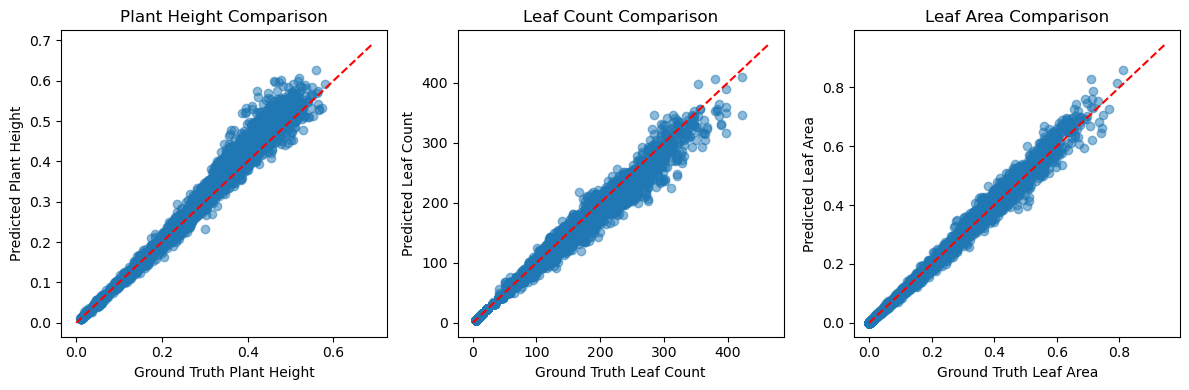

In [ ]:
# Create comparison plots
if True:
    # Set up figure for comparison plots
    fig, axs = plt.subplots(1, 3, figsize=(12, 4))
    
    # Plant Height comparison
    if 'Plant Height_gt' in measurements_df.columns and 'Plant Height_pred' in measurements_df.columns:
        axs[0].scatter(measurements_df['Plant Height_gt'], measurements_df['Plant Height_pred'], alpha=0.5)
        max_height = max(measurements_df['Plant Height_gt'].max(), measurements_df['Plant Height_pred'].max()) * 1.1
        axs[0].plot([0, max_height], [0, max_height], 'r--')
        axs[0].set_xlabel('Ground Truth Plant Height')
        axs[0].set_ylabel('Predicted Plant Height')
        axs[0].set_title('Plant Height Comparison')
        
    # Leaf Count comparison
    if 'Leaf Count_gt' in measurements_df.columns and 'Leaf Count_pred' in measurements_df.columns:
        axs[1].scatter(measurements_df['Leaf Count_gt'], measurements_df['Leaf Count_pred'], alpha=0.5)
        max_leaf_count = max(measurements_df['Leaf Count_gt'].max(), measurements_df['Leaf Count_pred'].max()) * 1.1
        axs[1].plot([0, max_leaf_count], [0, max_leaf_count], 'r--')
        axs[1].set_xlabel('Ground Truth Leaf Count')
        axs[1].set_ylabel('Predicted Leaf Count')
        axs[1].set_title('Leaf Count Comparison')
    
    # Leaf Area comparison
    if 'Leaf Area_gt' in measurements_df.columns and 'Leaf Area_pred' in measurements_df.columns:
        valid_leaf_area = measurements_df[(measurements_df['Leaf Area_gt'] > 0) & (measurements_df['Leaf Area_pred'] > 0)]
        if len(valid_leaf_area) > 0:
            axs[2].scatter(valid_leaf_area['Leaf Area_gt'], valid_leaf_area['Leaf Area_pred'], alpha=0.5)
            max_leaf_area = max(valid_leaf_area['Leaf Area_gt'].max(), valid_leaf_area['Leaf Area_pred'].max()) * 1.1
            axs[2].plot([0, max_leaf_area], [0, max_leaf_area], 'r--')
            axs[2].set_xlabel('Ground Truth Leaf Area')
            axs[2].set_ylabel('Predicted Leaf Area')
            axs[2].set_title('Leaf Area Comparison')
    
    plt.tight_layout()
    plt.savefig(f"{output_folder}/measurement_comparison.png")
    
    print(f"Comparison plots saved to {output_folder}")

print(f"All processing complete for {output_folder}")

In [ ]:
import os
import numpy as np
from tqdm import tqdm
from string_to_xml_to_vec import xml2vec, linked_to_recursive
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt

def process_xml_files(dataset_dir, file_suffix):
    xml_files = [f for f in os.listdir(dataset_dir) if f.endswith(file_suffix)]
    xml_files.sort()
    plant_array = []
    for xml_file in tqdm(xml_files):
        xml_file = os.path.join(dataset_dir, xml_file)
        tree = ET.parse(xml_file)
        root = tree.getroot()
        root = linked_to_recursive(root)
        for plant_instance in root:
            plant_instance_array = []
            xml2vec(plant_instance, plant_instance_array)
            plant_array.append(plant_instance_array)
    return plant_array

def extract_params(plant_array):
    all_shoot_params = []
    all_internode_params = []
    all_petiole_params = []
    all_leaf_params = []
    for token in plant_array:
        for vec in token:
            organ_type = vec[1]
            if organ_type == 0:
                all_shoot_params.append(vec[2:])
            elif organ_type == 1:
                all_internode_params.append(vec[2:])
            elif organ_type == 2:
                all_petiole_params.append(vec[2:])
            elif organ_type == 3:
                all_leaf_params.append(vec[2:])
    return (np.array(all_shoot_params), np.array(all_internode_params), np.array(all_petiole_params), np.array(all_leaf_params))

In [ ]:
# GT 데이터셋 처리
gt_dataset_dir = f"{output_folder}/xml"
gt_plant_array = process_xml_files(gt_dataset_dir, '_gt.xml')

# EST 데이터셋 처리
est_dataset_dir = gt_dataset_dir
est_plant_array = process_xml_files(est_dataset_dir, '_pred.xml')



# Find the minimum length between the two arrays
min_length = min(len(gt_plant_array), len(est_plant_array))

gt_plant_array = gt_plant_array[:min_length]
est_plant_array = est_plant_array[:min_length]
gt_shoot_params, gt_internode_params, gt_petiole_params, gt_leaf_params = extract_params(gt_plant_array)
est_shoot_params, est_internode_params, est_petiole_params, est_leaf_params = extract_params(est_plant_array)


100%|███████████████████████████████████████| 4000/4000 [01:00<00:00, 66.50it/s]


/tmp/ipykernel_343901/1561983683.py:39: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(x_min - margin, x_max + margin)


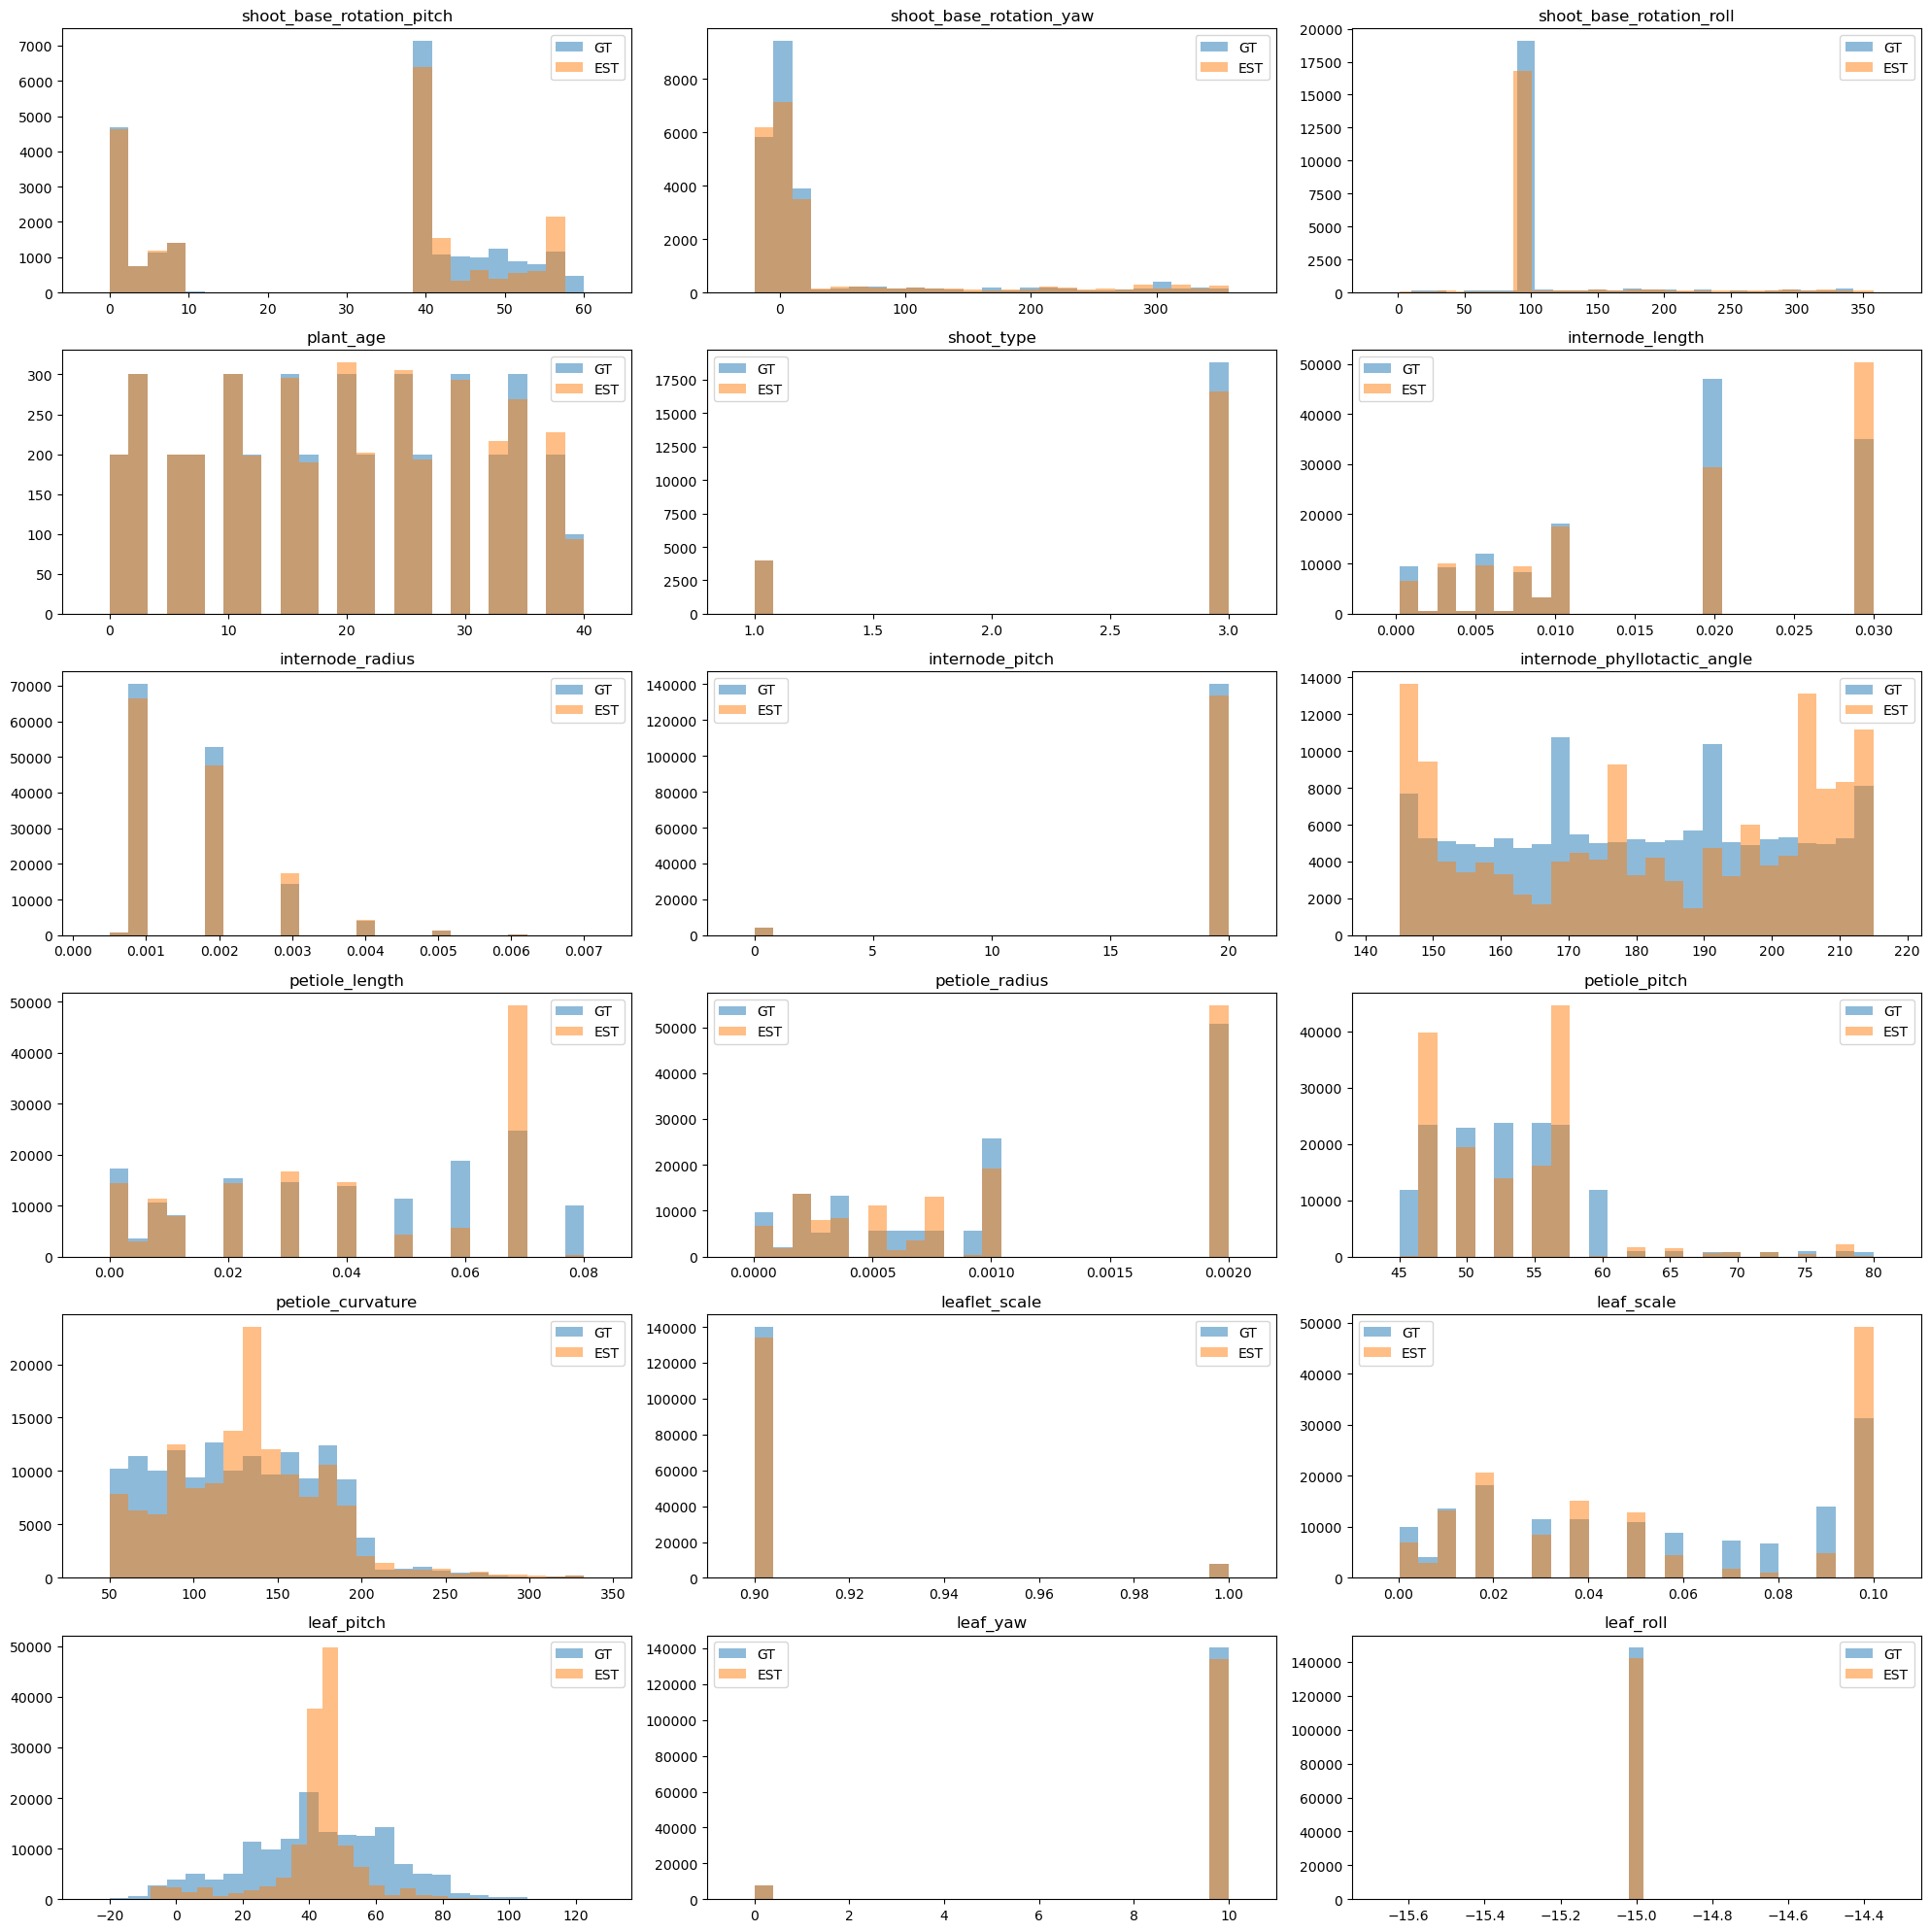

In [ ]:
# Plant age
gt_plant_age = np.array([x[0][5] for x in gt_plant_array])
est_plant_age = np.array([x[0][5] for x in est_plant_array])

# 파라미터 추출
params = [
    (gt_shoot_params[:, 0], est_shoot_params[:, 0], "shoot_base_rotation_pitch"),
    (gt_shoot_params[:, 1], est_shoot_params[:, 1], "shoot_base_rotation_yaw"),
    (gt_shoot_params[:, 2], est_shoot_params[:, 2], "shoot_base_rotation_roll"),
    (gt_plant_age, est_plant_age, "plant_age"),
    (gt_shoot_params[:, 4], est_shoot_params[:, 4], "shoot_type"),
    (gt_internode_params[:, 0], est_internode_params[:, 0], "internode_length"),
    (gt_internode_params[:, 1], est_internode_params[:, 1], "internode_radius"),
    (gt_internode_params[:, 2], est_internode_params[:, 2], "internode_pitch"),
    (gt_internode_params[:, 3], est_internode_params[:, 3], "internode_phyllotactic_angle"),
    (gt_petiole_params[:, 0], est_petiole_params[:, 0], "petiole_length"),
    (gt_petiole_params[:, 1], est_petiole_params[:, 1], "petiole_radius"),
    (gt_petiole_params[:, 2], est_petiole_params[:, 2], "petiole_pitch"),
    (gt_petiole_params[:, 3], est_petiole_params[:, 3], "petiole_curvature"),
    (gt_petiole_params[:, 4], est_petiole_params[:, 4], "leaflet_scale"),
    (gt_leaf_params[:, 0], est_leaf_params[:, 0], "leaf_scale"),
    (gt_leaf_params[:, 1], est_leaf_params[:, 1], "leaf_pitch"),
    (gt_leaf_params[:, 2], est_leaf_params[:, 2], "leaf_yaw"),
    (gt_leaf_params[:, 3], est_leaf_params[:, 3], "leaf_roll")
]

# 그래프 그리기
fig, axes = plt.subplots(nrows=6, ncols=3, figsize=(20, 20))
axes = axes.flatten()

for ax, (gt_param, est_param, title) in zip(axes, params):
    ax.hist(gt_param, bins=25, alpha=0.5, label='GT')
    ax.hist(est_param, bins=25, alpha=0.5, label='EST')

    # Add margin to the X-axis
    x_min = min(gt_param.min(), est_param.min())
    x_max = max(gt_param.max(), est_param.max())
    margin = (x_max - x_min) * 0.10  # 10% margin
    ax.set_xlim(x_min - margin, x_max + margin)
    ax.set_title(title)
    ax.legend()

plt.tight_layout()
plt.show()